# Metody i techniki sztucznej inteligencji

## Zadanie zaliczeniowe - klasyfikacja
<b>IMIĘ I NAZWISKO</b>

https://www.kaggle.com/datasets/mujtabamatin/air-quality-and-pollution-assessment

**Zadanie 1.**
Wczytaj niezbędne biblioteki

In [1]:
pip install pandas seaborn matplotlib scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential

**Zadanie 2.** Załaduj zbiór danych

In [3]:
pollution = pd.read_csv("updated_pollution_dataset.csv")

**Zadanie 3.** Wyświetl 5 pierwszych wierszy zbioru

In [5]:
pollution.head(5)

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


**Zadanie 4.** Wyświetl 5 ostatnich wierszy zbioru

In [6]:
pollution.tail(5)

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
4995,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous
4996,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate
4997,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate
4998,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good
4999,24.1,77.9,81.7,94.3,23.2,10.5,1.38,8.3,461,Moderate


**Zadanie 5.** Wyświetl typy danych w zbiorze

In [7]:
pollution.dtypes

Temperature                      float64
Humidity                         float64
PM2.5                            float64
PM10                             float64
NO2                              float64
SO2                              float64
CO                               float64
Proximity_to_Industrial_Areas    float64
Population_Density                 int64
Air Quality                       object
dtype: object

**Zadanie 6.** Wyświetl rozmiary zbioru

In [8]:
pollution.size

50000

**Zadanie 7.** Wyświetl wszystkie statystyki

In [9]:
pollution.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


**Zadanie 8.** Sprawdź czy zbiór zawiera duplikaty

In [13]:
pollution.duplicated().any().any()

np.False_

**Zadanie 9.** Sprawdź czy zbiór zawiera brakujące wartości - isna

In [11]:
pollution.isna().any().any()

np.False_

**Zadanie 10.** Sprawdź czy zbiór zawiera brakujące wartości - null

In [12]:
pollution.isnull().any().any()

np.False_

**Zadanie 11.** Zamień kolumny kategoryczne na numeryczne

In [4]:
le = LabelEncoder()
pollution['Air Quality'] = le.fit_transform(pollution['Air Quality'])

In [17]:
pollution['Air Quality'].head(10)

0    2
1    2
2    2
3    0
4    0
5    1
6    3
7    2
8    3
9    3
Name: Air Quality, dtype: int64

**Zadanie 12.** Wyświetl wykresy par zmiennych względem Air Quality

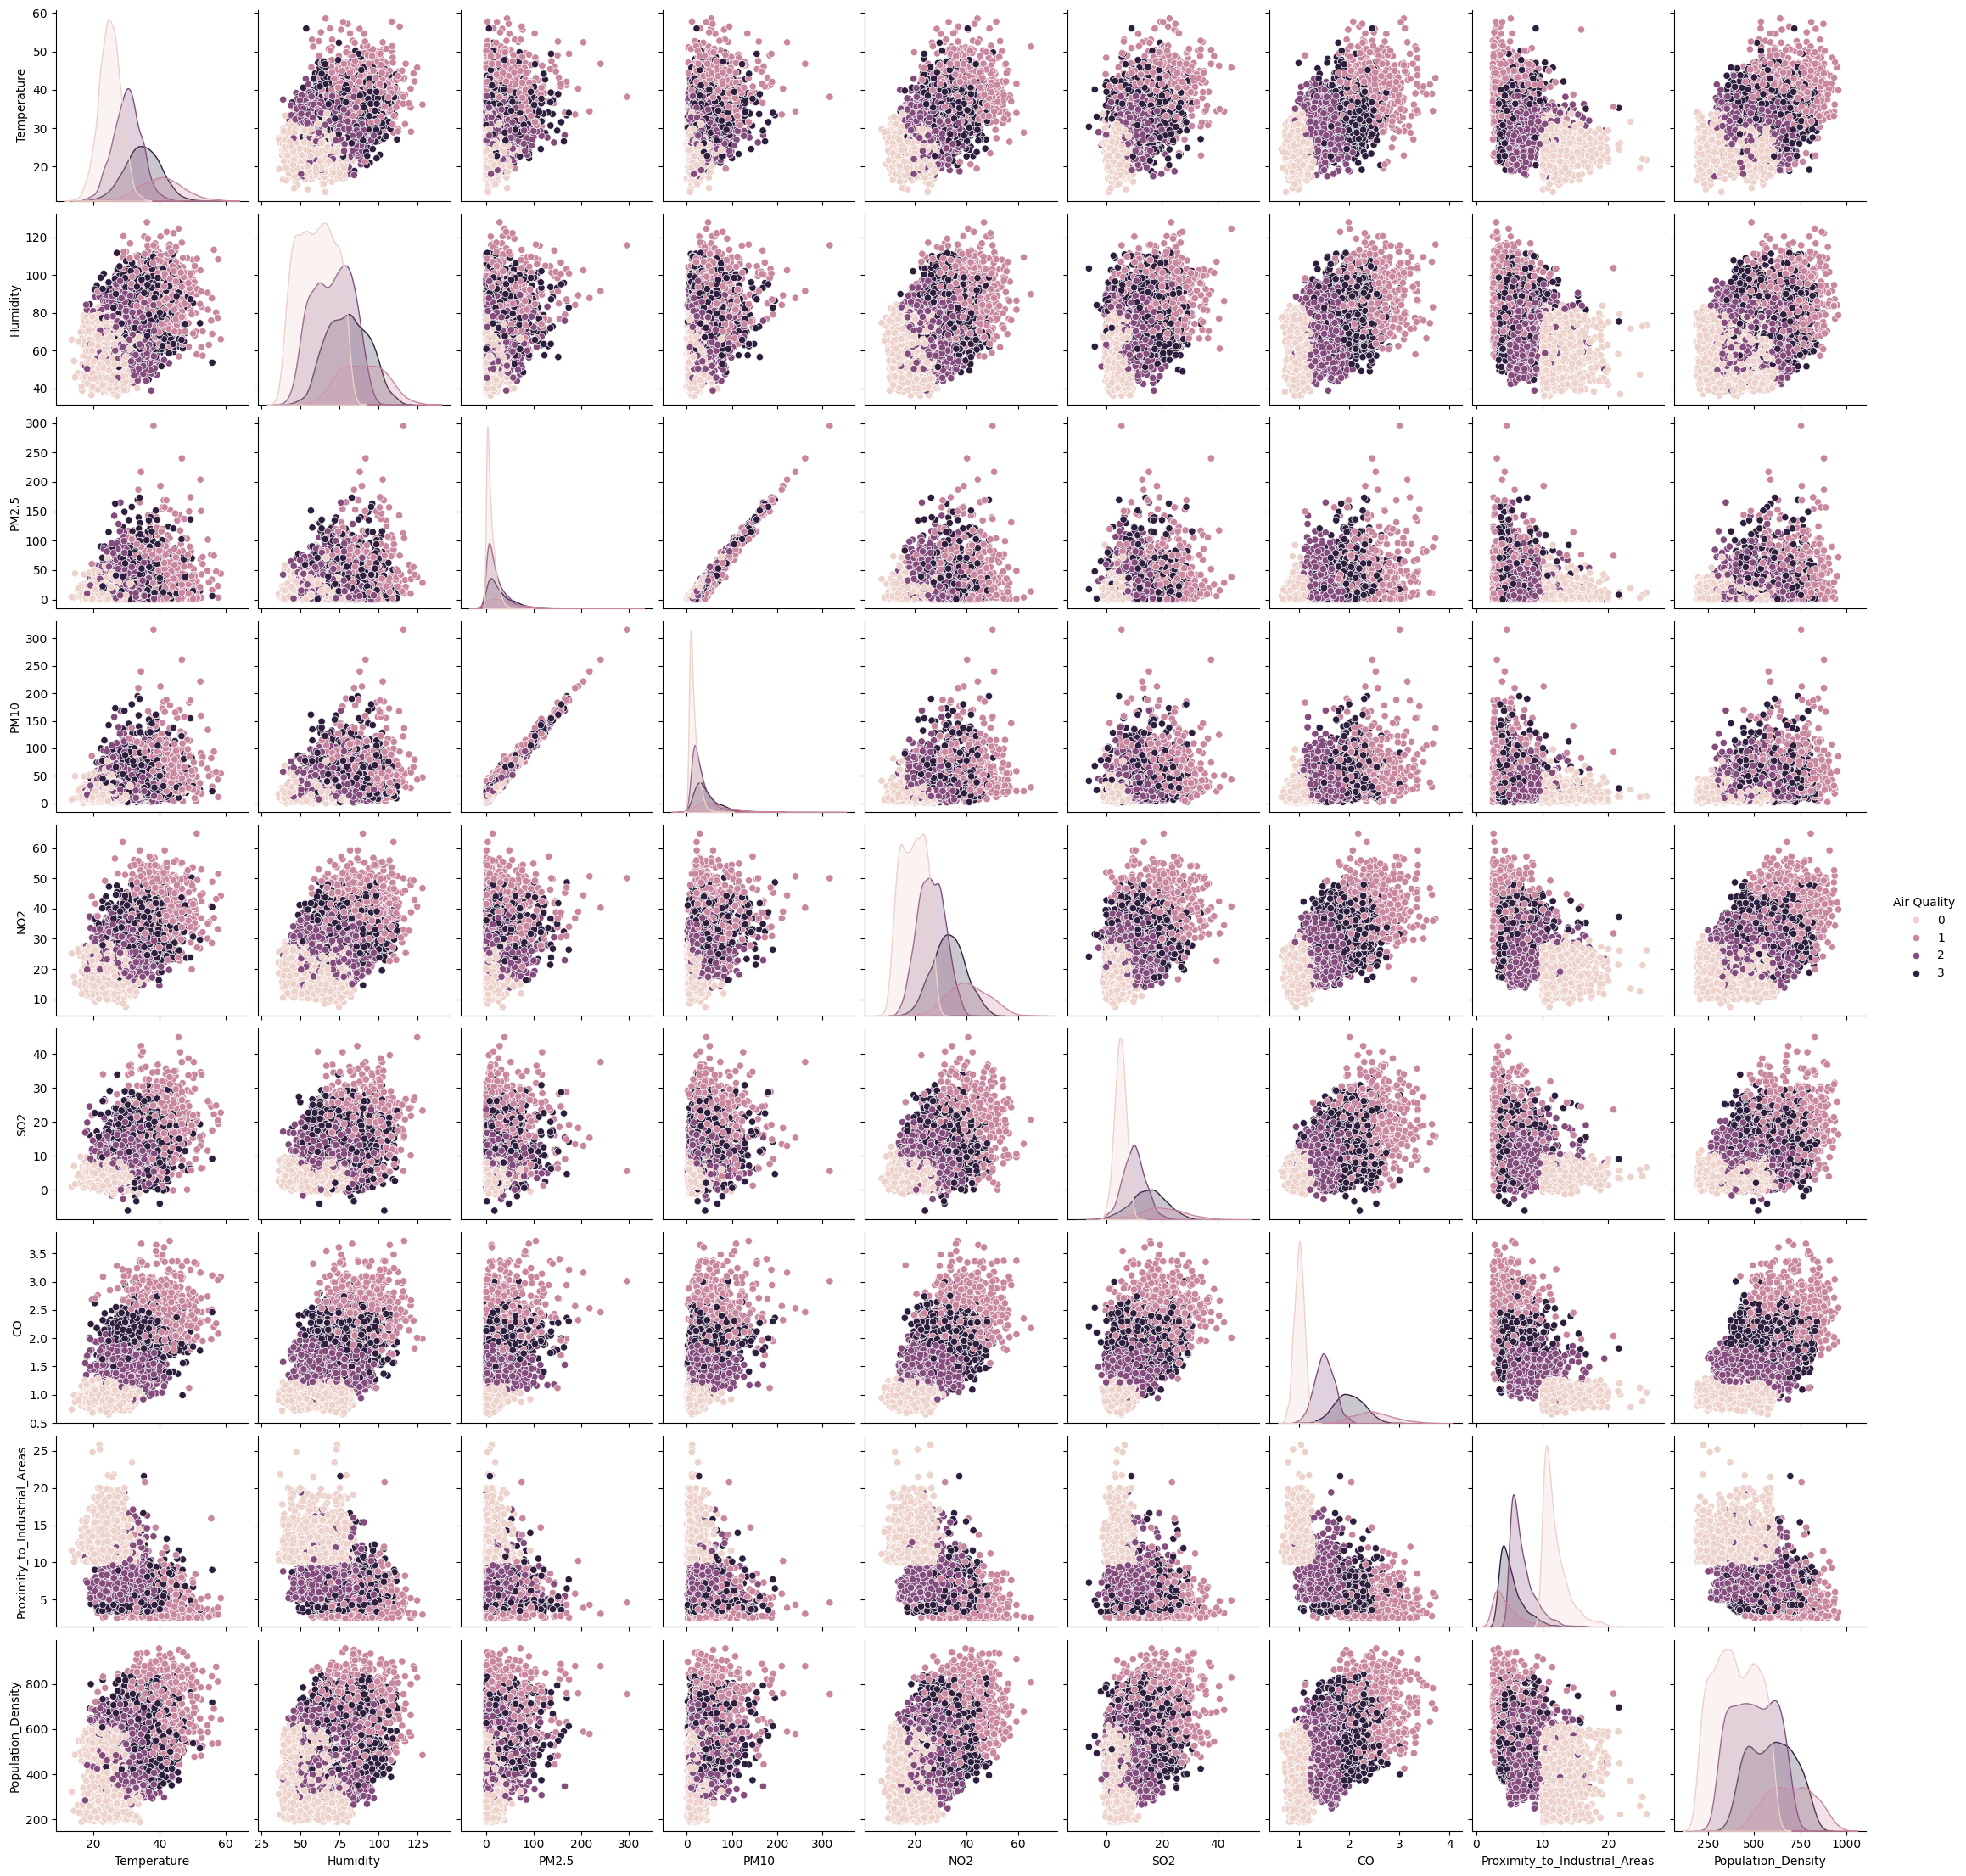

In [18]:
sns.pairplot(pollution, hue='Air Quality')
plt.show()

**Zadanie 13.** Podziel zbiór danych na X i y - Air Quality

In [5]:
X = pollution.drop('Air Quality', axis=1)
y = pollution['Air Quality']

**Zadanie 14.** Przeskaluj/znormalizuj lub ustandaryzuj X

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head(5)

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
0,-0.034080,-0.690715,-0.608589,-0.450455,-0.844581,-0.120721,0.402303,-0.588658,-1.168163
1,-0.257295,0.349507,-0.726706,-0.658892,0.493329,-0.046643,0.255775,-0.671748,0.743598
2,-1.031106,0.292768,0.267100,0.130973,-0.226219,0.383011,0.237459,-0.893318,0.795975
3,-0.435867,-1.951591,-0.571933,-0.874642,-1.451700,-0.698530,-0.641707,0.740767,0.350770
4,-0.525153,0.040593,-0.539349,-0.519934,-0.507293,-0.654083,-0.898130,1.183909,-1.272917


**Zadanie 15.** Podziel zbiór danych na treningowy i testowy

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

**Zadanie 16.** Stwórz model sieci z warstw w pełni połączonych - ostatnia warstwa ma 4 wyjścia, a jej funkcja aktywacji to softmax

In [8]:
input_layer = Input(shape=(X_train.shape[1],))
x = Dense(64, activation='relu')(input_layer)
x = Dense(32, activation='relu')(x)
output_layer = Dense(4, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output_layer)

**Zadanie 17.** Ustaw funkcję kosztu (sparse_categorical_crossentropy ), optymalizator oraz metryki

In [9]:
optimizer = Adam()
loss_function = 'sparse_categorical_crossentropy'
metrics = ['accuracy']

**Zadanie 18.** Zbuduj model

In [10]:
model.compile(optimizer=optimizer, loss=loss_function, metrics=metrics)

**Zadanie 19.** Wyświetl podsumowanie modelu

In [11]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,852 (11.14 KB)

 Trainable params: 2,852 (11.14 KB)

 Non-trainable params: 0 (0.00 B)

**Zadanie 20.** Ustaw liczbę epok i wytrenuj model zapisując go do zmiennej *history*

In [18]:
epochs = 100
history = model.fit(X_train, y_train, epochs=epochs, validation_data=(X_test, y_test))

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9880 - loss: 0.0378 - val_accuracy: 0.9440 - val_loss: 0.2418
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9899 - loss: 0.0275 - val_accuracy: 0.9430 - val_loss: 0.2133
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9891 - loss: 0.0380 - val_accuracy: 0.9390 - val_loss: 0.2132
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9918 - loss: 0.0298 - val_accuracy: 0.9440 - val_loss: 0.2093
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9895 - loss: 0.0323 - val_accuracy: 0.9460 - val_loss: 0.2118
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9889 - loss: 0.0331 - val_accuracy: 0.9450 - val_loss: 0.2202
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9897 - loss: 0.0312 - val_accuracy: 0.9460 - val_loss: 0.2277
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9905 - loss: 0.0301 - val_accu

**Zadanie 21.** Wyświetl wykres dokładności dla danych treningowych

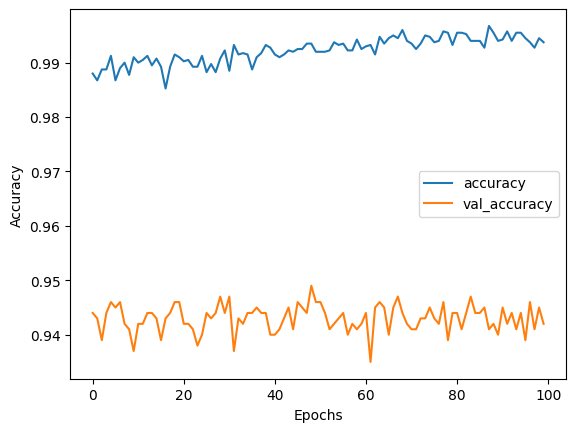

In [20]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Zadanie 22.** Zredukuj wymiarowość X do 2 cech za pomocą PCA

In [22]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

**Zadanie 23.** Podziel zbiór danych X_pca na treningowy i testowy

In [23]:
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

**Zadanie 24.** Stwórz model sieci z warstw w pełni połączonych - ostatnia warstwa ma 4 wyjścia, a jej funkcja aktywacji to softmax

In [24]:
model = Sequential()
model.add(Input(shape=(X_train_pca.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(4, activation='softmax'))

**Zadanie 25.** Ustaw funkcję kosztu (sparse_categorical_crossentropy ), optymalizator oraz metryki

In [25]:
optimizer = Adam()
loss_function = 'sparse_categorical_crossentropy'
metrics = ['accuracy']

**Zadanie 26.** Zbuduj model

In [26]:
model.compile(optimizer=optimizer, loss=loss_function, metrics=metrics)

**Zadanie 27.** Wyświetl podsumowanie modelu

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,404 (9.39 KB)

 Trainable params: 2,404 (9.39 KB)

 Non-trainable params: 0 (0.00 B)

**Zadanie 28.** Ustaw liczbę epok i wytrenuj model zapisując go do zmiennej *history*

In [28]:
epochs = 100
history = model.fit(
	X_train_pca,
	y_train,
	epochs=epochs,
	validation_data=(X_test_pca, y_test)
)

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6063 - loss: 1.0049 - val_accuracy: 0.8680 - val_loss: 0.4551
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8725 - loss: 0.4052 - val_accuracy: 0.9150 - val_loss: 0.2744
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9098 - loss: 0.2716 - val_accuracy: 0.9110 - val_loss: 0.2408
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9049 - loss: 0.2426 - val_accuracy: 0.9150 - val_loss: 0.2173
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9189 - loss: 0.2185 - val_accuracy: 0.9180 - val_loss: 0.2129
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9146 - loss: 0.2173 - val_accuracy: 0.9180 - val_loss: 0.2243
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9099 - loss: 0.2246 - val_accuracy: 0.9130 - val_loss: 0.2117
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9093 - loss: 0.2177 - val_accu

**Zadanie 29.** Wyświetl wykres dokładności dla danych treningowych

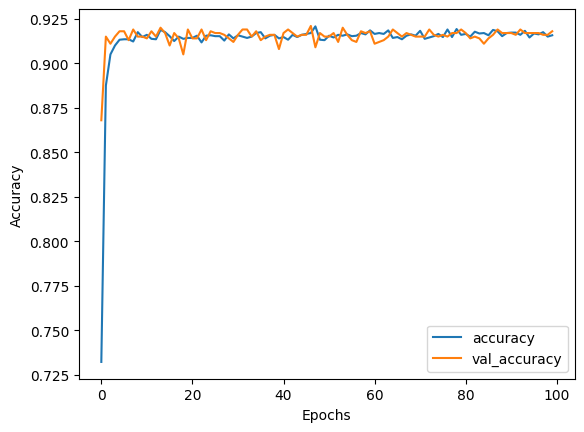

In [30]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

**Zadanie 30.** Wyświetl dane po redukcji wymiarowości

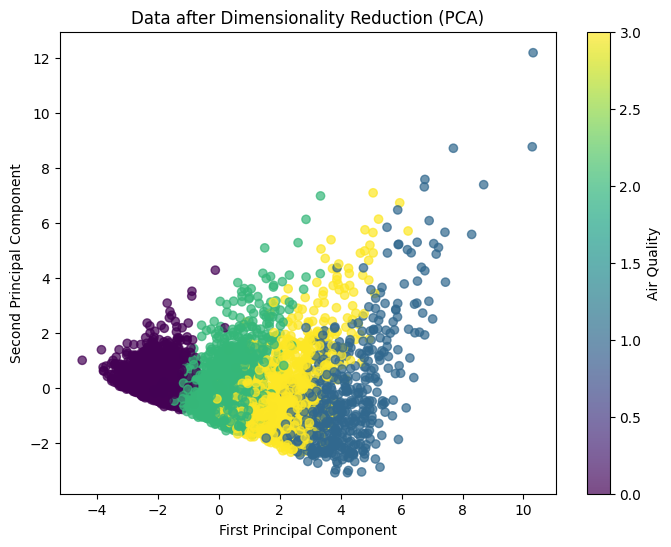

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, alpha=0.7)
plt.colorbar(label='Air Quality')  # Dodanie legendy, by wskazać, jak etykiety są reprezentowane
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Data after Dimensionality Reduction (PCA)')
plt.show()

In [35]:
def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = np.argmax(Z, axis=1) 
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

**Zadanie 31.** Wyświetl regiony decyzyjne wytrenowanej sieci neuronowej

22734/22734 ━━━━━━━━━━━━━━━━━━━━ 23s 987us/step


C:\Users\aleks\AppData\Local\Temp\ipykernel_212\983829258.py:22: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


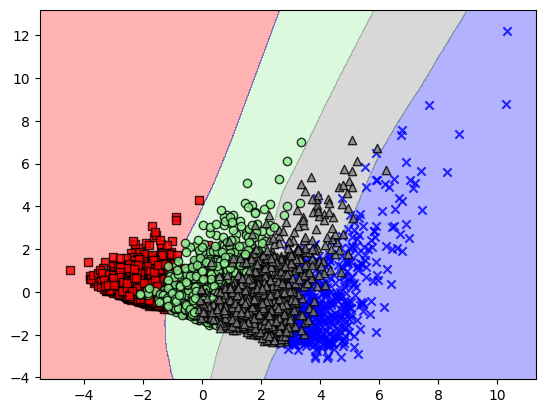

In [39]:
from matplotlib.colors import ListedColormap

plot_decision_regions(X_pca, y, classifier=model, resolution=0.02)